In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
df = pd.read_csv("../data/raw/wearable_health_devices.csv")
df.head()

,user_id,date,age,gender,region,device_model,height_cm,weight_kg,bmi,resting_hr_bpm,...,sleep_duration_hours,sleep_efficiency,sleep_latency_min,wake_after_sleep_onset_min,sleep_stage_rem_pct,sleep_stage_deep_pct,sleep_stage_light_pct,stress_score,mindfulness_minutes,mood
0,U0001,2025-05-11,35,female,TR-EasternAnatolia,FitPulse X,170,58.7,20.3,71.481219,...,6.846974,0.915716,14.0,39.0,0.289,0.144,0.567,55,3,bad
1,U0001,2025-05-12,35,female,TR-EasternAnatolia,FitPulse X,170,58.7,20.3,67.964498,...,7.103551,0.944442,25.0,38.0,0.209,0.204,0.588,58,0,very_bad
2,U0001,2025-05-13,35,female,TR-EasternAnatolia,FitPulse X,170,58.7,20.3,66.760038,...,7.954798,0.859938,19.0,32.0,0.203,0.189,0.608,50,8,good
3,U0001,2025-05-14,35,female,TR-EasternAnatolia,FitPulse X,170,58.7,20.3,65.008374,...,7.375435,0.970183,12.0,40.0,0.211,0.159,0.630,54,12,neutral
4,U0001,2025-05-15,35,female,TR-EasternAnatolia,FitPulse X,170,58.7,20.3,67.528909,...,7.569236,0.916390,8.0,23.0,0.236,0.206,0.558,55,0,neutral


Reduces dataset size to 54,143 rows (removing the 1,057 rows with missing activity/sleep metrics).

In [29]:
df = df.dropna()
df.shape

(54143, 33)

Bin the target stress_score using the optimal thresholds [18, 62, 72, 100] found in EDA.

In [30]:
df["stress_class"] = pd.cut(
    df["stress_score"],
    bins=[18, 62, 72, 100],
    labels=["Low", "Moderate", "High"],
    include_lowest=True
)

df["stress_class"].value_counts()

stress_class
Low         18937
Moderate    17766
High        17440
Name: count, dtype: int64

user_id
→ just identifies the person

date
→ not using date information in our first model

stress_score
→ this is what stress_class was created from
  keeping it would give the model the answer

distance_km
→ almost identical to steps

sleep_stage_rem_pct
→ deep + light + REM ≈ 1
  so one sleep stage is redundant

In [31]:
df = df.drop(
    columns=[
        "user_id",
        "date",
        "distance_km",
        "sleep_stage_rem_pct"
    ]
)

One-hot encode the categorical variables, dropping the first category (drop_first=True) to avoid the dummy variable trap.

In [32]:
df = pd.get_dummies(
    df,
    columns=[
        "gender",
        "region",
        "device_model",
        "workout_type",
        "mood"
    ],
    drop_first=True
)

for e.g. for a gender column containing ["male", "female", "other"], pd.get_dummies() transforms it into three separate columns:

gender_female (1 if female, 0 otherwise)
gender_male (1 if male, 0 otherwise)
gender_other (1 if other, 0 otherwise)

In [33]:
df['gender_male'].head()

0    False
1    False
2    False
3    False
4    False
Name: gender_male, dtype: bool

In [34]:
df.columns.tolist()

['age',
 'height_cm',
 'weight_kg',
 'bmi',
 'resting_hr_bpm',
 'avg_hr_day_bpm',
 'hrv_rmssd_ms',
 'spo2_avg_pct',
 'sbp_mmHg',
 'dbp_mmHg',
 'steps',
 'calories_kcal',
 'workout_minutes',
 'caffeine_mg',
 'alcohol_units',
 'screen_time_min',
 'sleep_duration_hours',
 'sleep_efficiency',
 'sleep_latency_min',
 'wake_after_sleep_onset_min',
 'sleep_stage_deep_pct',
 'sleep_stage_light_pct',
 'stress_score',
 'mindfulness_minutes',
 'stress_class',
 'gender_male',
 'gender_other',
 'region_TR-BlackSea',
 'region_TR-CentralAnatolia',
 'region_TR-EasternAnatolia',
 'region_TR-Marmara',
 'region_TR-Mediterranean',
 'region_TR-Southeastern',
 'device_model_HealthBand Pro',
 'device_model_PulseOne Mini',
 'device_model_SleepSense 2',
 'device_model_VitalWatch 4',
 'workout_type_mixed',
 'workout_type_none',
 'workout_type_run',
 'workout_type_strength',
 'workout_type_walk',
 'workout_type_yoga',
 'mood_good',
 'mood_neutral',
 'mood_very_bad',
 'mood_very_good']

In [35]:
df.shape

(54143, 47)

In [36]:
df.to_csv(
    "../data/processed/wearable_health_processed.csv",
    index=False
)

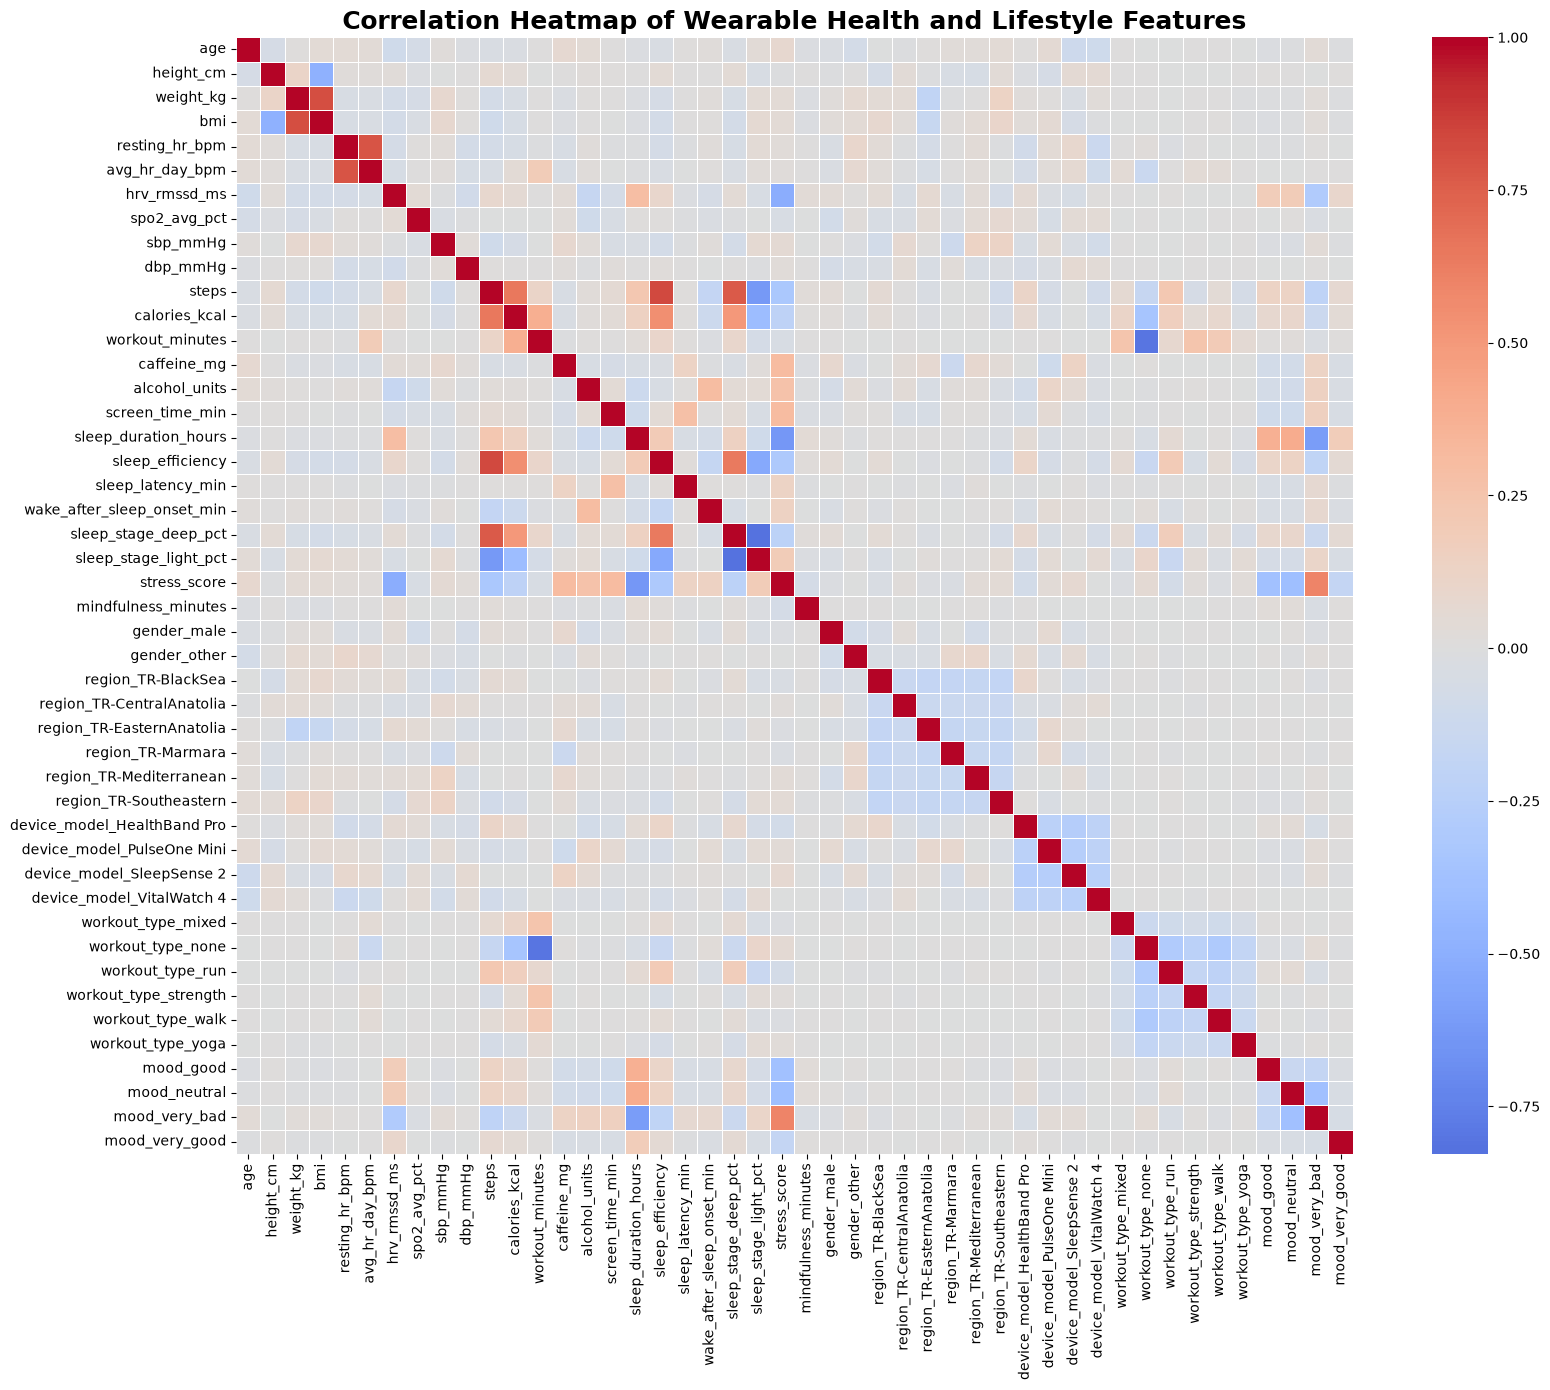

In [37]:
# ==============================
# CORRELATION HEATMAP
# ==============================



# Correlation matrix


correlation_matrix = df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(18,14))

sns.heatmap(
    correlation_matrix,
    annot=False,
    cmap="coolwarm",
    center=0,
    linewidths=0.4,
    square=True
)

plt.title("Correlation Heatmap of Wearable Health and Lifestyle Features",
          fontsize=18,
          fontweight="bold")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

Correlation of Features with Stress Score
sleep_duration_hours          -0.630609
mood_very_bad                  0.598700
hrv_rmssd_ms                  -0.507283
mood_neutral                  -0.396161
mood_good                     -0.373619
steps                         -0.325982
sleep_efficiency              -0.310545
screen_time_min                0.310006
caffeine_mg                    0.305548
alcohol_units                  0.260985
sleep_stage_deep_pct          -0.225564
calories_kcal                 -0.213708
sleep_stage_light_pct          0.188583
mood_very_good                -0.174079
wake_after_sleep_onset_min     0.139404
sleep_latency_min              0.133804
device_model_HealthBand Pro   -0.081325
workout_type_run              -0.075326
age                            0.074806
mindfulness_minutes           -0.069275
device_model_SleepSense 2      0.066575
workout_type_none              0.052116
sbp_mmHg                       0.051874
region_TR-Southeastern         0.04994

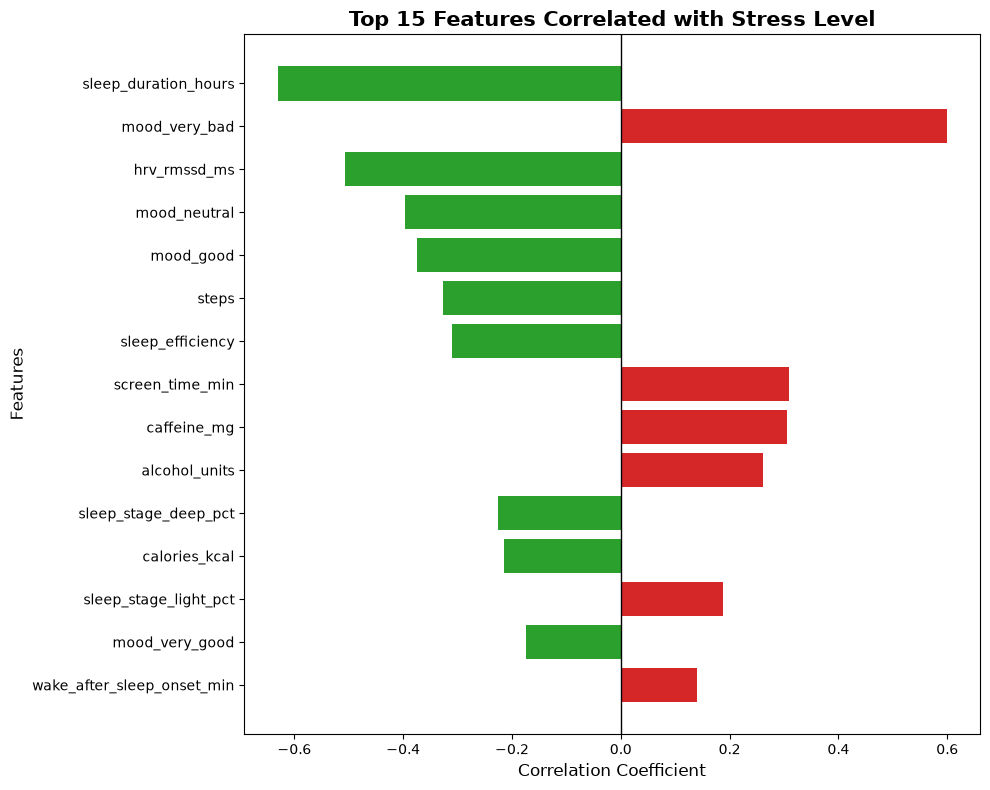

In [39]:
# ===========================================
# CORRELATION WITH STRESS SCORE
# ===========================================

stress_correlation = (
    correlation_matrix["stress_score"]
    .drop("stress_score")
    .sort_values(key=abs, ascending=False)
)

print("Correlation of Features with Stress Score")
print(stress_correlation)

# Plot top 15 correlations
# top15 = stress_correlation.head(15)

# plt.figure(figsize=(8,7))

# colors = ["green" if value < 0 else "red" for value in top15.values]

# plt.barh(top15.index, top15.values, color=colors)

# plt.xlabel("Correlation Coefficient")
# plt.title("Top Features Correlated with Stress Score")

# plt.gca().invert_yaxis()

# plt.tight_layout()
# plt.show()
top15 = stress_correlation.head(15)

plt.figure(figsize=(10,8))

colors = ["#D62728" if value > 0 else "#2CA02C"
          for value in top15.values]

plt.barh(
    top15.index,
    top15.values,
    color=colors
)

plt.axvline(x=0, color="black", linewidth=1)

plt.xlabel("Correlation Coefficient", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.title(
    "Top 15 Features Correlated with Stress Level",
    fontsize=15,
    fontweight="bold"
)

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()